In [239]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### loading the csv data

In [240]:
df=pd.read_csv('titanic.csv')
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [241]:
# (1309,11)--->1309 row and coloumn
df.shape

(1309, 11)

In [242]:
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0


In [243]:
df.columns
# pclass --> passenger class
# name --> lname,courtesy_title.fname
# sex --> gender (lower case)
# age --> float (years +months)
# sibsp --> sibling +spouse count
# parch --> parents+childrens count
# ticket --> alphanumric ( )
# fare --> amount (float)
# cabin --> cabin name
# embarked --> port name
# survived --> died(0),alive(1)

Index(['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'cabin', 'embarked', 'survived'],
      dtype='str')

### Data Cleaninig

1. check for duplicate and handle them

2. check for missing value and handle them

3. check for invalid datatype and handle them

4. remove the unwanted coloumn

In [244]:
df.duplicated().any()  # false  (no duplicate value in data set)
# Do you have any pk_coloumn  --> no but if you have such then
# df['pk_col'].duplicated().any()

np.False_

In [245]:
df.info()
# missing data in 
# -->(numrical) age, fare and (text)cabin,embarked
# --> cabin is having more null values hence we need drop it
# --> check for outlear in num_cols(age ,fare) and if outlear are present then choose median else means for fillen
# --> embarked is categorical coloumn hence we need to choose mode()
# -->  

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   str    
 2   sex       1309 non-null   str    
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   str    
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    str    
 9   embarked  1307 non-null   str    
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 112.6 KB


<Axes: xlabel='age'>

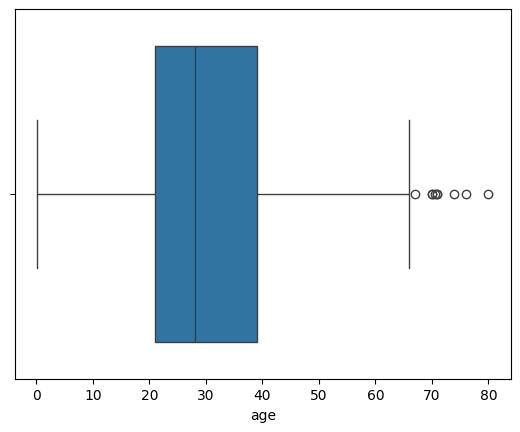

In [246]:
sns.boxplot(df,x='age')

<Axes: xlabel='fare'>

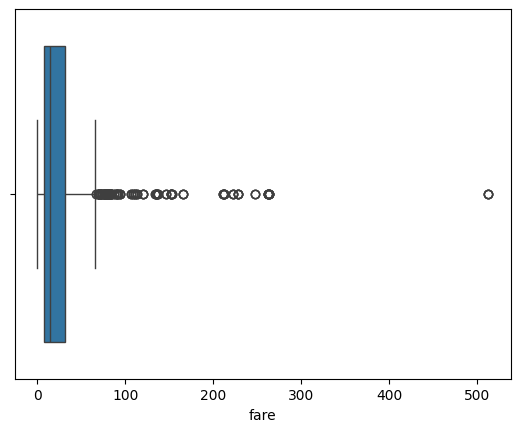

In [247]:
sns.boxplot(df,x='fare')
# plt.show()


In [248]:
age_md=df['fare'].median() #28.0
fare_md=df['fare'].median() # 14.45
df['embarked'].mode()  # return type is deries which consist of cell value  's' in indexing _pos-->0
emb_mod=df['embarked'].mode()[0]

In [249]:
col_names=['age','fare','embarked']
values=[age_md,fare_md,emb_mod]
# list(zip(col_names,values))
for col,val in zip(col_names,values):
    df[col]=df[col].fillna(val)


In [250]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   str    
 2   sex       1309 non-null   str    
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   str    
 7   fare      1309 non-null   float64
 8   cabin     295 non-null    str    
 9   embarked  1309 non-null   str    
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 112.6 KB


In [251]:
df.describe()

,pclass,age,sibsp,parch,fare,survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,2.294882,26.781605,0.498854,0.385027,33.281086,0.381971
std,0.837836,14.290388,1.041658,0.865560,51.741500,0.486055
min,1.000000,0.166700,0.000000,0.000000,0.000000,0.000000
25%,2.000000,14.454200,0.000000,0.000000,7.895800,0.000000
50%,3.000000,24.000000,0.000000,0.000000,14.454200,0.000000
75%,3.000000,35.000000,1.000000,0.000000,31.275000,1.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,1.000000


In [252]:
df.dropna(axis=1)

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S,0
...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,C,0
1305,3,"Zabour, Miss. Thamine",female,14.4542,1,0,2665,14.4542,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,C,0


In [253]:
df=df.dropna(axis=1)

In [254]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   str    
 2   sex       1309 non-null   str    
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   str    
 7   fare      1309 non-null   float64
 8   embarked  1309 non-null   str    
 9   survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 102.4 KB


In [255]:
# all coloumns are having valid data type

## Data tranformation(feature engineering) 

In [256]:
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S,0


In [257]:
df['pclass'].unique() # no transformation requraid

array([1, 2, 3])

In [258]:
df['name'].str.split(',',expand=True) #return type of list

,0,1
0,Allen,Miss. Elisabeth Walton
1,Allison,Master. Hudson Trevor
2,Allison,Miss. Helen Loraine
3,Allison,Mr. Hudson Joshua Creighton
4,Allison,Mrs. Hudson J C (Bessie Waldo Daniels)
...,...,...
1304,Zabour,Miss. Hileni
1305,Zabour,Miss. Thamine
1306,Zakarian,Mr. Mapriededer
1307,Zakarian,Mr. Ortin


In [259]:
df[['lname','temp']]=df['name'].str.split(',',expand=True)

In [260]:
df['temp'].str.split('.',expand=True,n=1)

,0,1
0,Miss,Elisabeth Walton
1,Master,Hudson Trevor
2,Miss,Helen Loraine
3,Mr,Hudson Joshua Creighton
4,Mrs,Hudson J C (Bessie Waldo Daniels)
...,...,...
1304,Miss,Hileni
1305,Miss,Thamine
1306,Mr,Mapriededer
1307,Mr,Ortin


In [261]:
df[['courtesy_title','fname']]=df['temp'].str.split('.',expand=True,n=1)

In [262]:
df=df.drop(columns=['name','temp'])

In [263]:
for i in ['fname','lname','courtesy_title']:
    df[i]=df[i].str.strip()

In [264]:
df.head(2)

,pclass,sex,age,sibsp,parch,ticket,fare,embarked,survived,lname,courtesy_title,fname
0,1,female,29.0000,0,0,24160,211.3375,S,1,Allen,Miss,Elisabeth Walton
1,1,male,0.9167,1,2,113781,151.5500,S,1,Allison,Master,Hudson Trevor


In [265]:
df.rename(columns={'sex':'gender'})

,pclass,gender,age,sibsp,parch,ticket,fare,embarked,survived,lname,courtesy_title,fname
0,1,female,29.0000,0,0,24160,211.3375,S,1,Allen,Miss,Elisabeth Walton
1,1,male,0.9167,1,2,113781,151.5500,S,1,Allison,Master,Hudson Trevor
2,1,female,2.0000,1,2,113781,151.5500,S,0,Allison,Miss,Helen Loraine
3,1,male,30.0000,1,2,113781,151.5500,S,0,Allison,Mr,Hudson Joshua Creighton
4,1,female,25.0000,1,2,113781,151.5500,S,0,Allison,Mrs,Hudson J C (Bessie Waldo Daniels)
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,female,14.5000,1,0,2665,14.4542,C,0,Zabour,Miss,Hileni
1305,3,female,14.4542,1,0,2665,14.4542,C,0,Zabour,Miss,Thamine
1306,3,male,26.5000,0,0,2656,7.2250,C,0,Zakarian,Mr,Mapriededer
1307,3,male,27.0000,0,0,2670,7.2250,C,0,Zakarian,Mr,Ortin


In [266]:
df=df.rename(columns={'sex':'gender'})

In [267]:
df['gender'].str.title()

0       Female
1         Male
2       Female
3         Male
4       Female
         ...  
1304    Female
1305    Female
1306      Male
1307      Male
1308      Male
Name: gender, Length: 1309, dtype: str

In [268]:
df['gender']=df['gender'].str.title()

In [269]:
df['age'].round(1)

0       29.0
1        0.9
2        2.0
3       30.0
4       25.0
        ... 
1304    14.5
1305    14.5
1306    26.5
1307    27.0
1308    29.0
Name: age, Length: 1309, dtype: float64

In [270]:
df['age']=df['age'].round(1)

In [271]:
df['sibsp']+df['parch']

0       0
1       3
2       3
3       3
4       3
       ..
1304    1
1305    1
1306    0
1307    0
1308    0
Length: 1309, dtype: int64

In [272]:
df['fam_count']=df['sibsp']+df['parch']

In [273]:
df.sort_values('ticket',ascending=True).reset_index(drop=True)

,pclass,gender,age,sibsp,parch,ticket,fare,embarked,survived,lname,courtesy_title,fname,fam_count
0,1,Female,30.0,0,0,110152,86.500,S,1,Cherry,Miss,Gladys,0
1,1,Female,33.0,0,0,110152,86.500,S,1,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards),0
2,1,Female,16.0,0,0,110152,86.500,S,1,Maioni,Miss,Roberta,0
3,1,Female,18.0,0,2,110413,79.650,S,1,Taussig,Miss,Ruth,2
4,1,Female,39.0,1,1,110413,79.650,S,1,Taussig,Mrs,Emil (Tillie Mandelbaum),2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Female,47.0,1,0,W.E.P. 5734,61.175,S,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood),1
1305,1,Male,46.0,1,0,W.E.P. 5734,61.175,S,0,Chaffee,Mr,Herbert Fuller,1
1306,2,Male,30.0,0,0,W/C 14208,10.500,S,0,Harris,Mr,Walter,0
1307,1,Male,70.0,1,1,WE/P 5735,71.000,S,0,Crosby,Capt,Edward Gifford,2


In [274]:
df=df.sort_values('ticket',ascending=True).reset_index(drop=True)

In [275]:
# df['embarked'].unique()
print(df['embarked'].nunique(),end='\n\n')
print(df['embarked'].unique())

df['embarked']=df['embarked'].replace({'S':'southampton','C':'charbourg','Q':'queenstown'})

3

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


In [276]:
df.columns

Index(['pclass', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'embarked', 'survived', 'lname', 'courtesy_title', 'fname',
       'fam_count'],
      dtype='str')

In [277]:
col_names=['ticket','courtesy_title','fname','lname','sibsp','parch','gender','age','fam_count','embarked','pclass','fare','survived']

df=df[col_names]

In [278]:
df.head(20)

,ticket,courtesy_title,fname,lname,sibsp,parch,gender,age,fam_count,embarked,pclass,fare,survived
0,110152,Miss,Gladys,Cherry,0,0,Female,30.0,0,southampton,1,86.5000,1
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,0,0,Female,33.0,0,southampton,1,86.5000,1
2,110152,Miss,Roberta,Maioni,0,0,Female,16.0,0,southampton,1,86.5000,1
3,110413,Miss,Ruth,Taussig,0,2,Female,18.0,2,southampton,1,79.6500,1
4,110413,Mrs,Emil (Tillie Mandelbaum),Taussig,1,1,Female,39.0,2,southampton,1,79.6500,1
5,110413,Mr,Emil,Taussig,1,1,Male,52.0,2,southampton,1,79.6500,0
6,110465,Mr,Walter Chamberlain,Porter,0,0,Male,47.0,0,southampton,1,52.0000,0
7,110465,Mr,George Quincy,Clifford,0,0,Male,14.5,0,southampton,1,52.0000,0
8,110469,Mr,John Edward,Maguire,0,0,Male,30.0,0,southampton,1,26.0000,0
9,110489,Mr,John James,Borebank,0,0,Male,42.0,0,southampton,1,26.5500,0


In [279]:
df=df.drop(columns=['sibsp','parch'])

df.head()

,ticket,courtesy_title,fname,lname,gender,age,fam_count,embarked,pclass,fare,survived
0,110152,Miss,Gladys,Cherry,Female,30.0,0,southampton,1,86.50,1
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,Female,33.0,0,southampton,1,86.50,1
2,110152,Miss,Roberta,Maioni,Female,16.0,0,southampton,1,86.50,1
3,110413,Miss,Ruth,Taussig,Female,18.0,2,southampton,1,79.65,1
4,110413,Mrs,Emil (Tillie Mandelbaum),Taussig,Female,39.0,2,southampton,1,79.65,1


In [280]:
df['ticket'].value_counts()

ticket
CA. 2343       11
1601            8
CA 2144         8
3101295         7
347077          7
               ..
W./C. 14260     1
W./C. 14263     1
W./C. 14266     1
W./C. 6609      1
W/C 14208       1
Name: count, Length: 929, dtype: int64

In [281]:
tit_cnt=df['ticket'].value_counts()
tit_cnt==1

ticket
CA. 2343       False
1601           False
CA 2144        False
3101295        False
347077         False
               ...  
W./C. 14260     True
W./C. 14263     True
W./C. 14266     True
W./C. 6609      True
W/C 14208       True
Name: count, Length: 929, dtype: bool

In [282]:
# tit_cnt=df['ticket'].value_counts()
# psg_cnt_df=tit_cnt[tit_cnt==1].reset_index()
psg_cnt_df=df['ticket'].value_counts().reset_index()
psg_cnt_df

,ticket,count
0,CA. 2343,11
1,1601,8
2,CA 2144,8
3,3101295,7
4,347077,7
...,...,...
924,W./C. 14260,1
925,W./C. 14263,1
926,W./C. 14266,1
927,W./C. 6609,1


In [283]:
# psg_cnt_df=df['ticket'].value_counts().reset_index()
# psg_cnt_df
# pd.merge(df,psg_cnt_df)
#-----------------------or------------------------------
p=dict(df['ticket'].value_counts()) # series
p=dict(p)
df['ticket'].map(p)

0       3
1       3
2       3
3       3
4       3
       ..
1304    2
1305    2
1306    1
1307    2
1308    2
Name: ticket, Length: 1309, dtype: int64

In [284]:
df['psg_cnt']=df['ticket'].map(p)

In [285]:
df

,ticket,courtesy_title,fname,lname,gender,age,fam_count,embarked,pclass,fare,survived,psg_cnt
0,110152,Miss,Gladys,Cherry,Female,30.0,0,southampton,1,86.500,1,3
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,Female,33.0,0,southampton,1,86.500,1,3
2,110152,Miss,Roberta,Maioni,Female,16.0,0,southampton,1,86.500,1,3
3,110413,Miss,Ruth,Taussig,Female,18.0,2,southampton,1,79.650,1,3
4,110413,Mrs,Emil (Tillie Mandelbaum),Taussig,Female,39.0,2,southampton,1,79.650,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,W.E.P. 5734,Mrs,Herbert Fuller (Carrie Constance Toogood),Chaffee,Female,47.0,1,southampton,1,61.175,1,2
1305,W.E.P. 5734,Mr,Herbert Fuller,Chaffee,Male,46.0,1,southampton,1,61.175,0,2
1306,W/C 14208,Mr,Walter,Harris,Male,30.0,0,southampton,2,10.500,0,1
1307,WE/P 5735,Capt,Edward Gifford,Crosby,Male,70.0,2,southampton,1,71.000,0,2


In [286]:
df['fare']                                              

0       86.500
1       86.500
2       86.500
3       79.650
4       79.650
         ...  
1304    61.175
1305    61.175
1306    10.500
1307    71.000
1308    71.000
Name: fare, Length: 1309, dtype: float64

In [287]:
df['fare']/df['psg_cnt']

0       28.833333
1       28.833333
2       28.833333
3       26.550000
4       26.550000
          ...    
1304    30.587500
1305    30.587500
1306    10.500000
1307    35.500000
1308    35.500000
Length: 1309, dtype: float64

In [288]:
(df['fare']/df['psg_cnt']).round(1)

0       28.8
1       28.8
2       28.8
3       26.6
4       26.6
        ... 
1304    30.6
1305    30.6
1306    10.5
1307    35.5
1308    35.5
Length: 1309, dtype: float64

In [289]:
# assigne the ne pare
df['fare']=(df['fare']/df['psg_cnt']).round(1)

In [290]:
df.head(2)

,ticket,courtesy_title,fname,lname,gender,age,fam_count,embarked,pclass,fare,survived,psg_cnt
0,110152,Miss,Gladys,Cherry,Female,30.0,0,southampton,1,28.8,1,3
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,Female,33.0,0,southampton,1,28.8,1,3


In [291]:
def companion_type(r):
    f=r['fam_count']
    p=r['psg_cnt']

    if p==1:
        return 'solo'
    else:
        if f==0:
            return 'friends'
        else:
            return 'family'
        
df['companion type']=df.apply(companion_type,axis=1)

In [292]:
df['age']

0       30.0
1       33.0
2       16.0
3       18.0
4       39.0
        ... 
1304    47.0
1305    46.0
1306    30.0
1307    70.0
1308    36.0
Name: age, Length: 1309, dtype: float64

In [293]:
df.head(2)

,ticket,courtesy_title,fname,lname,gender,age,fam_count,embarked,pclass,fare,survived,psg_cnt,companion type
0,110152,Miss,Gladys,Cherry,Female,30.0,0,southampton,1,28.8,1,3,friends
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,Female,33.0,0,southampton,1,28.8,1,3,friends


In [294]:
df['age_category']=pd.cut(df['age'],bins=[0,2,18,25,59,100],labels=['infant','child','teen','adult','seng'])

In [295]:
df['courtesy_title'].unique()

<StringArray>
[        'Miss', 'the Countess',          'Mrs',           'Mr',
           'Dr',        'Major',       'Master',          'Col',
         'Lady',     'Jonkheer',          'Rev',           'Ms',
         'Mlle',          'Mme',          'Sir',          'Don',
         'Dona',         'Capt']
Length: 18, dtype: str

In [318]:
def social_status(val):
    if val in []:
        return 'common'
    elif val in []:
        return 'royal'
    elif val in []:
        return 'professional'
    else:
        return 'other'

df['social status']=df['courtesy_title'].apply(social_status)

In [316]:
df.head(2)

,ticket,courtesy_title,fname,lname,gender,age,fam_count,embarked,pclass,fare,survived,psg_cnt,companion type,age_category,social status
0,110152,Miss,Gladys,Cherry,Female,30.0,0,southampton,1,28.8,1,3,friends,adult,None
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,Female,33.0,0,southampton,1,28.8,1,3,friends,adult,None


In [298]:
new_order=[        'Miss', 'the Countess',          'Mrs',           'Mr',
           'Dr',        'Major',       'Master',          'Col',
         'Lady',     'Jonkheer',          'Rev',           'Ms',
         'Mlle',          'Mme',          'Sir',          'Don',
         'Dona',         'Capt']


In [299]:
def social_status(val):
    if val in ['Mrs','Mr','Miss','Master','Ms',]:
        return 'common'
    elif val in []:
        return 'royal'
    elif val in []:
        return 'professional'
    else:
        return 'other'

df['social status']=df['courtesy_title'].apply(social_status)

### DATA ANALYSIS

1. NO OF passenger in each pclass

In [300]:
df['pclass'].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

**oberrvation**

pclass  3 is having more pasenger following pclass 1 and pclass 2

2. gender wise no of psgs

In [301]:
df['gender'].value_counts()

gender
Male      843
Female    466
Name: count, dtype: int64

**obervation**

male psgs count is almost the doubl of female psg count

3. avg_age of psgs in each pclass and gender

In [302]:
df.groupby(['gender','pclass']).agg({'age':'mean'}).round()

age
gender pclass      
Female 1       35.0
       2       27.0
       3       20.0
Male   1       37.0
       2       30.0
       3       23.0

4. gender wise total_fare

In [303]:
df.groupby('gender').agg({'fare':'sum'})

,fare
gender,
Female,7912.3
Male,11405.4


**obervation**

male psgs are paying higher than female psgs

5. get the embarked in which higest no of psgs are present

In [304]:
df['embarked'].value_counts()

embarked
southampton    916
charbourg      270
queenstown     123
Name: count, dtype: int64

In [305]:
df['embarked'].value_counts().idxmax()  # higest passenger

'southampton'

6. get the female psgs who are solo travelers 

In [306]:
df.loc[  (df['gender']=='Female')  &  (df['companion type']=='solo')  ]

,ticket,courtesy_title,fname,lname,gender,age,fam_count,embarked,pclass,fare,survived,psg_cnt,companion type,age_category,social status
25,112053,Miss,Margaret Edith,Graham,Female,19.0,0,southampton,1,30.0,1,1,solo,teen,common
30,112377,Mrs,Carl Johan (Sigrid Posse),Lindstrom,Female,55.0,0,charbourg,1,27.7,1,1,solo,adult,common
34,112901,Mrs,Edward Gifford (Catherine Elizabeth Halstead),Crosby,Female,64.0,2,southampton,1,26.6,1,1,solo,seng,common
77,113783,Miss,Elizabeth,Bonnell,Female,58.0,0,southampton,1,26.6,1,1,solo,adult,common
88,113795,Miss,Constance,Willard,Female,21.0,0,southampton,1,26.6,1,1,solo,teen,common
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1286,STON/O2. 3101283,Miss,Eliina,Honkanen,Female,27.0,0,southampton,3,7.9,1,1,solo,adult,common
1287,STON/O2. 3101290,Miss,Wendla Maria,Heininen,Female,23.0,0,southampton,3,7.9,0,1,solo,teen,common
1290,W./C. 14258,Miss,Lucy,Ridsdale,Female,50.0,0,southampton,2,10.5,1,1,solo,adult,common
1293,W./C. 14266,Mrs,(Selena Rogers),Cook,Female,22.0,0,southampton,2,10.5,1,1,solo,teen,common


7. get the royal passenger pclass and fare and companion type

In [307]:
df.loc[  df['social status']=='Royal' , ['pclass','fare','companion type']  ]

,pclass,fare,companion type


8. how many adults belongs to royal psgs category

In [308]:
df.loc[(df['social status']=='Royal') & (df['age_category']=='Adult')].shape[0]

0

9. get the statical description for age and fare

In [309]:
df.describe() # all numerical coloumn
df[['age','fare']].describe()

,age,fare
count,1309.000000,1309.000000
mean,26.790833,14.757601
std,14.282406,13.550806
min,0.200000,0.000000
25%,14.500000,7.600000
50%,24.000000,8.000000
75%,35.000000,15.000000
max,80.000000,128.100000


**obervation**

1. 68% of passenger age lies b/w (16.6 to 42.4)year

2. 68% pasenger fare lies b/w (1.19 to 28.2)rs

3. 25% of passnger age lies below  22year , 75%  of psgs age lies below 35 year

4. 25% of fare lies below 7.6rs , 75% of psgs age lies below 15rs

5. 50% of psgs age , fare lies below 28 year and 8rs respectively

In [310]:
print(26.7-14.2 , 26.7+14.2 )

print(14.7-13.5 , 14.7+13.5)

print()

12.5 40.9
1.1999999999999993 28.2



10. plot the pclass  wise no of male and female

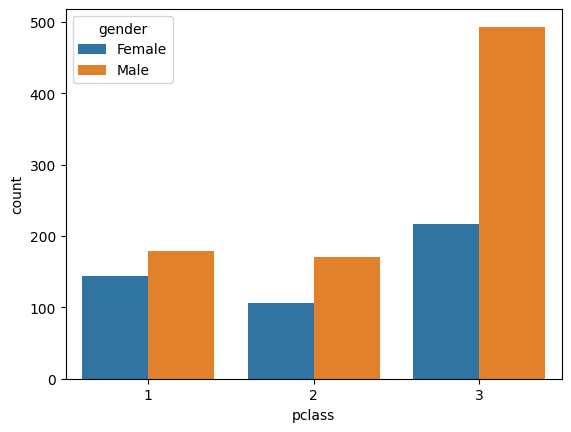

In [311]:
plt.Figure(figsize=(4,2))
sns.countplot(df,x='pclass',hue='gender')
plt.show()

**obervation**

pclass 3 has more psgs then other than pclass and most of male psgs are prefering the pclass 3

male psgs fare was near female psgs total fare might be bcz of the
resion (most of  male psgs perfering the pclass 3)

11. plot the porperties of psgs in each social_status

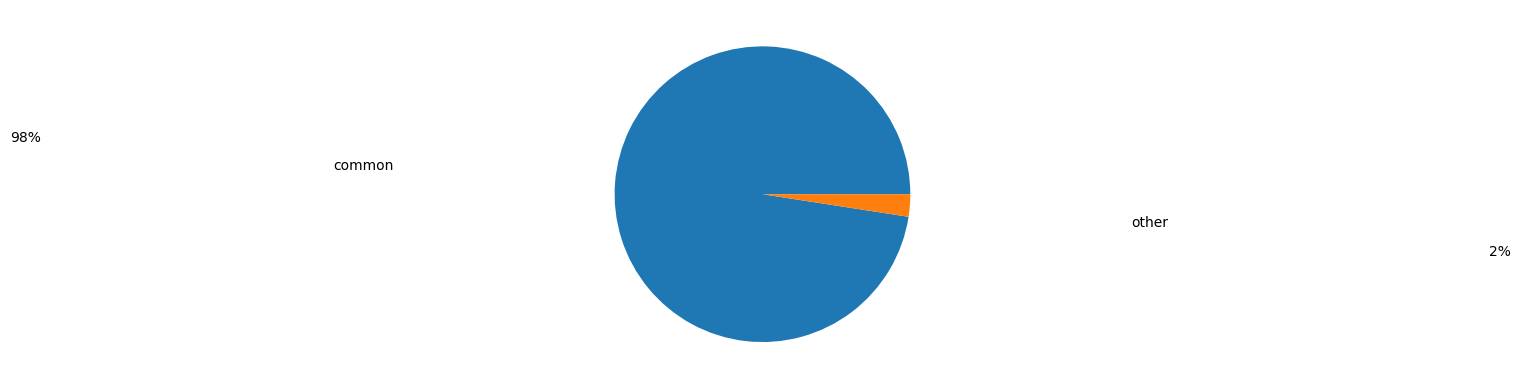

In [312]:
plt.Figure(figsize=(4,2))
s=df['social status'].value_counts()
plt.pie(x=s.values,labels=s.index,labeldistance=2.5,autopct='%.f%%',pctdistance=5)
plt.show()

**obervation**
almost all psgs belong to comm category and around 2.5 % psgs belong to royal and professional category

12. plot the distribution of passenger age

In [ ]:
plt.subplots(1,2,figsize=(5,2))
plt.suptitle('Distribution of age')
sns.histplot(df,x='age':,ax=axes[0])
sns.kdeplot(df,x='age',ax=axes[1])
plt.tight_layout()
plt.show()

**obervation**

psgs age is around 26 year and its is slightly right skewed

13. plot the correlation b/w pclass and fare  age survived coloumn

In [ ]:

c= df[['pclass','age','fare','survived']].corr()
sns.heatmap(c,annot=True,fmt='.1f',cmap='coolwarn')
plt.show()

**obervation**

pclass and fare show strong nagative corelation (as pclass value increase fare will be decrease with 80%)
survived of psgs is not strongly influenced by any factory

14. plot the relationship between age and fare 

In [ ]:
plt.Figure(figsize=(3,2))
sns.scatterplot(df,x='age',y='fare')
plt.show()

15.

In [ ]:
fig,axes= plt.Subplots(1,2,figsize=(5,2))
plt.suptitle('outliar detection')

sns.boxplot(df,x='age',ax=axes[0])
sns.boxplot(df,x='age',ax=axes[1])
plt.tight_layout()
plt.show()